## Introduction

# Algerian Forest Fires Analysis

This project analyzes the Algerian Forest Fires dataset to understand
the factors that contribute to forest fires and to build a machine
learning model that predicts fire occurrence.

## 📌 Problem Definition

This project aims to predict temperature using meteorological features from the Algerian Forest Fires dataset.

This is a **regression problem**, where the goal is to model the relationship between environmental variables and temperature.

Understanding these relationships can help analyze conditions that may contribute to forest fires.

## Load Dataset

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nitinchoudhary012/algerian-forest-fires-dataset/Algerian_forest_fires_dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/nitinchoudhary012/algerian-forest-fires-dataset/Algerian_forest_fires_dataset.csv')

## Dataset Overview

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


In [5]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

## Data Cleaning

In [6]:
df[df.isnull().any(axis = 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [7]:
df.drop(122, inplace = True)

In [8]:
df[df.isnull().any(axis = 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


The dataset contains data from two different regions. Data up to row 123 belongs to one region, and data from row 123 onwards belongs to another region. Therefore, we will create another column and assign codes 0 and 1 to these regions.

In [9]:

df.loc[:123, "Region"] = 0
df.loc[123:, "Region"] = 1

In [10]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [11]:
df.tail()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
242,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1.0
243,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1.0
244,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1.0
245,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1.0
246,30,9,2012,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,not fire,1.0


In [12]:
df = df.dropna().reset_index(drop = True)

In [13]:
df.drop(122, inplace = True)  # We are deleting this line because it contains the headings for the second region.

In [14]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [15]:
df.shape

(243, 15)

In [16]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

There are some spaces in the column names that need to be cleaned up.

In [17]:
df.columns = df.columns.str.strip()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    object 
 1   month        243 non-null    object 
 2   year         243 non-null    object 
 3   Temperature  243 non-null    object 
 4   RH           243 non-null    object 
 5   Ws           243 non-null    object 
 6   Rain         243 non-null    object 
 7   FFMC         243 non-null    object 
 8   DMC          243 non-null    object 
 9   DC           243 non-null    object 
 10  ISI          243 non-null    object 
 11  BUI          243 non-null    object 
 12  FWI          243 non-null    object 
 13  Classes      243 non-null    object 
 14  Region       243 non-null    float64
dtypes: float64(1), object(14)
memory usage: 30.4+ KB


In [19]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


As seen above, while all columns except the Classes column should have numeric content, we observe that they are taking object values, and we will correct this below.

In [20]:
df[["day","month","year","Temperature","RH","Ws"]] = df[["day","month","year","Temperature","RH","Ws"]].astype(int)

In [21]:
df[["Rain","FFMC","DMC","DC","ISI","BUI","FWI"]] = df[["Rain","FFMC","DMC","DC","ISI","BUI","FWI"]].astype(float)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    float64
dtypes: float64(8), int64(6), object(1)
memory usage: 30.4+ KB


Now it's just the way we wanted it.

## Exploratory Data Analysis

In [23]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [24]:
df["Classes"].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

The data was entered incorrectly, which is why they appear different. We will correct them. Additionally, we will assign a value of 0 to "not fired" data and 1 to "fired" data.

In [25]:
df["Classes"] = np.where(df["Classes"].str.contains("not fire"),0,1)

In [26]:
df["Classes"].value_counts(normalize=True)*100

Classes
1    56.378601
0    43.621399
Name: proportion, dtype: float64

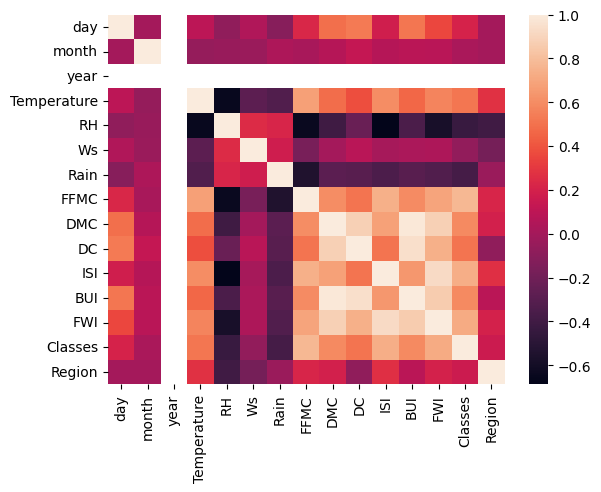

In [27]:
sns.heatmap(df.corr())
plt.show()

In [28]:
df.drop(["day","month","year"], axis = 1, inplace = True) # We don't need historical information in our current analysis.

## Modeling

In [29]:
# dependent & independent features
X = df.drop("FWI", axis = 1)
y = df["FWI"]

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [32]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.644824,-0.322405,-0.222809,0.600615,0.483815,0.362859,0.579809,0.452819,0.463959,0.229479
RH,-0.644824,1.000000,0.205669,0.171031,-0.643767,-0.395535,-0.204568,-0.682107,-0.337032,-0.427947,-0.368402
Ws,-0.322405,0.205669,1.000000,0.152948,-0.135584,0.011874,0.104577,0.021616,0.051452,-0.044791,-0.181246
Rain,-0.222809,0.171031,0.152948,1.000000,-0.475600,-0.263007,-0.282983,-0.325552,-0.276457,-0.363013,0.049735
FFMC,0.600615,-0.643767,-0.135584,-0.475600,1.000000,0.592446,0.483610,0.732549,0.577031,0.770641,0.158505
DMC,0.483815,-0.395535,0.011874,-0.263007,0.592446,1.000000,0.871387,0.658793,0.980646,0.549624,0.153781
DC,0.362859,-0.204568,0.104577,-0.282983,0.483610,0.871387,1.000000,0.467977,0.939248,0.468011,-0.120874
ISI,0.579809,-0.682107,0.021616,-0.325552,0.732549,0.658793,0.467977,1.000000,0.617313,0.714801,0.241664
BUI,0.452819,-0.337032,0.051452,-0.276457,0.577031,0.980646,0.939248,0.617313,1.000000,0.550431,0.044453
Classes,0.463959,-0.427947,-0.044791,-0.363013,0.770641,0.549624,0.468011,0.714801,0.550431,1.000000,0.136752


### Handling Multicollinearity

In machine learning models, some features may be highly correlated with each other. This situation is called **multicollinearity** and it can negatively affect model performance, especially for linear models. Highly correlated features often contain redundant information.

To reduce this problem, we compute the **correlation matrix** and identify pairs of features whose correlation is above a given threshold. If two features are strongly correlated, one of them is added to a list of columns to drop.

The function below automatically finds these highly correlated features so they can be removed from the dataset before training the model.


In [33]:
def correlation_of_dropping(df, treshold):
    columns_to_drop = set()
    corr = df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i,j]) > treshold:
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop                
        


In [34]:
columns_dropping = correlation_of_dropping(X_train, 0.85)
columns_dropping

{'BUI', 'DC'}

In [35]:
X_train.drop(columns_dropping, axis = 1, inplace = True)
X_test.drop(columns_dropping, axis = 1, inplace = True)

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [37]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Before moving on to Cross-Validation, we will look at different types of regression below.

Mean Absolute Error: 0.7036011729575926
Mean Squared Error: 0.8764163698605988
R2 Score: 0.9838729275348057


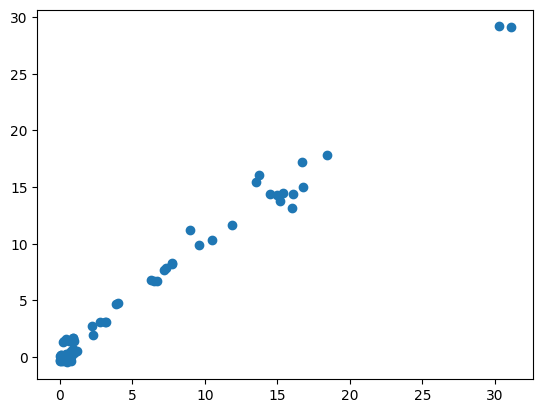

In [39]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred_lr = linear.predict(X_test_scaled)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)
print("Mean Absolute Error:", lr_mae)
print("Mean Squared Error:", lr_mse)
print("R2 Score:", lr_r2)
plt.scatter(y_test, y_pred_lr)
plt.show()

Mean Absolute Error: 1.216272633800629
Mean Squared Error: 2.6029377368132196
R2 Score: 0.9521029422229386


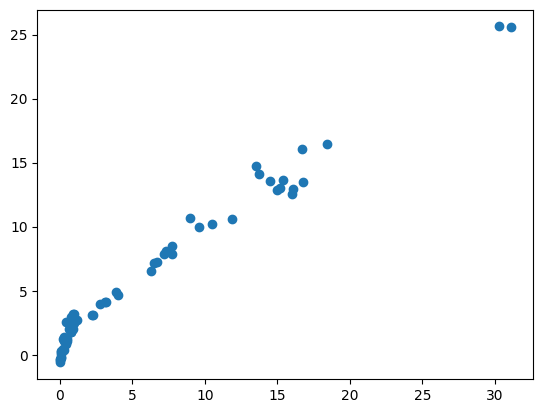

In [40]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)
print("Mean Absolute Error:", lasso_mae)
print("Mean Squared Error:", lasso_mse)
print("R2 Score:", lasso_r2)
plt.scatter(y_test, y_pred_lasso)
plt.show()

Mean Absolute Error: 0.709354244870332
Mean Squared Error: 0.8868348464263088
R2 Score: 0.9836812155445575


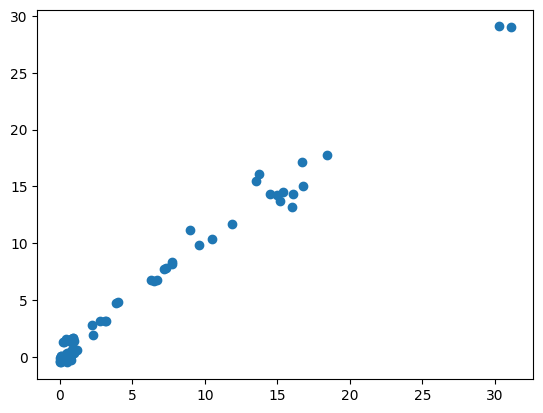

In [41]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)
print("Mean Absolute Error:", ridge_mae)
print("Mean Squared Error:", ridge_mse)
print("R2 Score:", ridge_r2)
plt.scatter(y_test, y_pred_ridge)
plt.show()

Mean Absolute Error: 1.749328647109016
Mean Squared Error: 5.569160502382824
R2 Score: 0.8975210207375391


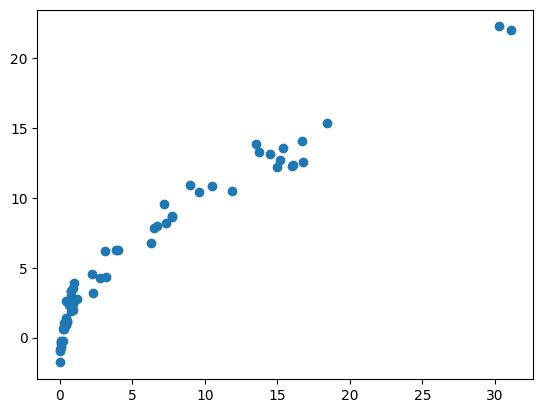

In [42]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet()
elastic.fit(X_train_scaled, y_train)
y_pred_enet = elastic.predict(X_test_scaled)
enet_mae = mean_absolute_error(y_test, y_pred_enet)
enet_mse = mean_squared_error(y_test, y_pred_enet)
enet_r2 = r2_score(y_test, y_pred_enet)
print("Mean Absolute Error:", enet_mae)
print("Mean Squared Error:", enet_mse)
print("R2 Score:", enet_r2)
plt.scatter(y_test, y_pred_enet)
plt.show()

Lasso Cross Validation


In [43]:
from sklearn.linear_model import LassoCV

Mean Absolute Error: 0.7222308156305418
Mean Squared Error: 0.8972011670293636
R2 Score: 0.9834904632842026


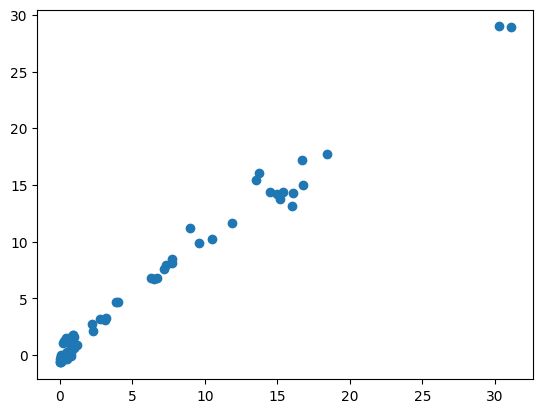

In [44]:
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled, y_train)

y_pred = lassocv.predict(X_test_scaled)

lassocv_mae = mean_absolute_error(y_test, y_pred)
lassocv_mse = mean_squared_error(y_test, y_pred)
lassocv_r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", lassocv_mae)
print("Mean Squared Error:", lassocv_mse)
print("R2 Score:", lassocv_r2)

plt.scatter(y_test, y_pred)
plt.show()

Ridge Cross Validation

Mean Absolute Error: 0.709354244870332
Mean Squared Error: 0.8868348464263088
R2 Score: 0.9836812155445575


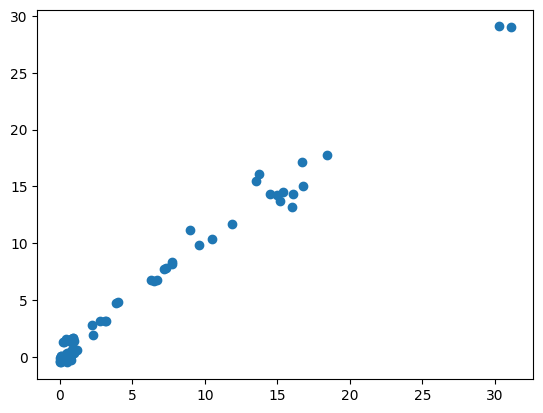

In [45]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_scaled, y_train)

y_pred_ridgecv = ridgecv.predict(X_test_scaled)

ridgecv_mae = mean_absolute_error(y_test, y_pred_ridgecv)
ridgecv_mse = mean_squared_error(y_test, y_pred_ridgecv)
ridgecv_r2 = r2_score(y_test, y_pred_ridgecv)

print("Mean Absolute Error:", ridgecv_mae)
print("Mean Squared Error:", ridgecv_mse)
print("R2 Score:", ridgecv_r2)

plt.scatter(y_test, y_pred_ridgecv)
plt.show()

Elastic Net Cross Validation

Mean Absolute Error: 0.7354284604918176
Mean Squared Error: 0.9249125778630378
R2 Score: 0.9829805413498388


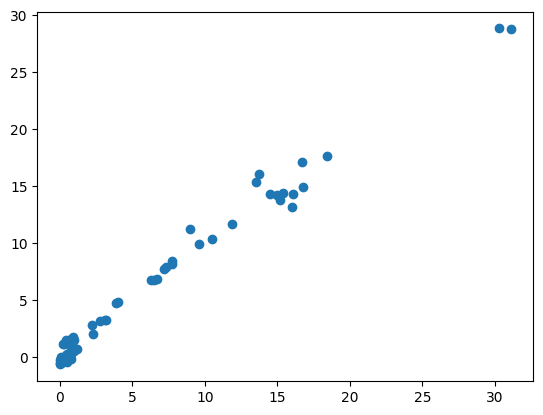

In [46]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv = ElasticNetCV(cv=5)
elasticnetcv.fit(X_train_scaled, y_train)

y_pred_enetcv = elasticnetcv.predict(X_test_scaled)

enetcv_mae = mean_absolute_error(y_test, y_pred_enetcv)
enetcv_mse = mean_squared_error(y_test, y_pred_enetcv)
enetcv_r2 = r2_score(y_test, y_pred_enetcv)

print("Mean Absolute Error:", enetcv_mae)
print("Mean Squared Error:", enetcv_mse)
print("R2 Score:", enetcv_r2)

plt.scatter(y_test, y_pred_enetcv)
plt.show()

In [47]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Lasso", "Ridge", "ElasticNet"],
    "R2 Score": [lr_r2, lasso_r2, ridge_r2, enet_r2],
    "MAE": [lr_mae, lasso_mae, ridge_mae, enet_mae],
    "MSE": [lr_mse, lasso_mse, ridge_mse, enet_mse]
})

results

,Model,R2 Score,MAE,MSE
0,Linear Regression,0.983873,0.703601,0.876416
1,Lasso,0.952103,1.216273,2.602938
2,Ridge,0.983681,0.709354,0.886835
3,ElasticNet,0.897521,1.749329,5.569161


In [48]:
cv_results = pd.DataFrame({
    "Model": ["Lasso", "Ridge", "ElasticNet"],
    "CV R2 Score": [lassocv_r2, ridgecv_r2, enetcv_r2],
    "CV MAE": [lassocv_mae, ridgecv_mae, enetcv_mae],
    "CV MSE": [lassocv_mse, ridgecv_mse, enetcv_mse]
})

cv_results

,Model,CV R2 Score,CV MAE,CV MSE
0,Lasso,0.983490,0.722231,0.897201
1,Ridge,0.983681,0.709354,0.886835
2,ElasticNet,0.982981,0.735428,0.924913


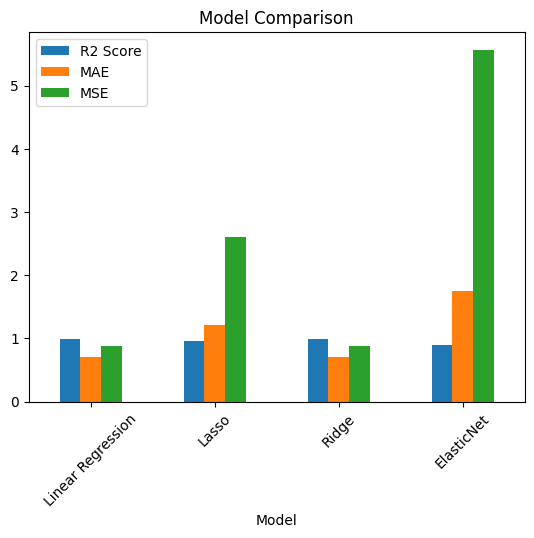

In [49]:
results.set_index("Model")[["R2 Score", "MAE", "MSE"]].plot(kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()


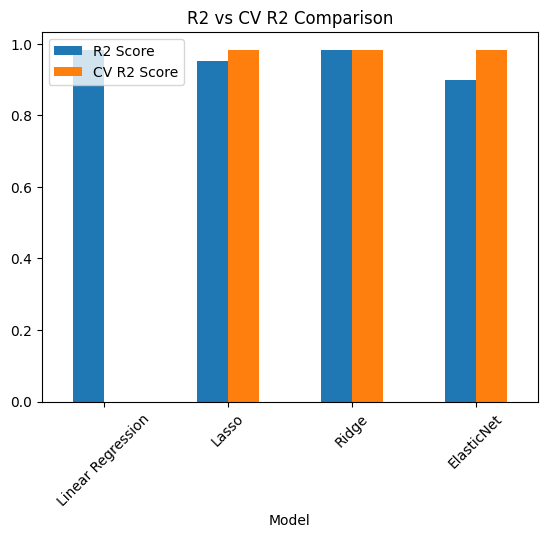

In [50]:
results["CV R2 Score"] = [None, lassocv_r2, ridgecv_r2, enetcv_r2]
results["CV MAE"] = [None, lassocv_mae, ridgecv_mae, enetcv_mae]
results["CV MSE"] = [None, lassocv_mse, ridgecv_mse, enetcv_mse]

results.set_index("Model")[["R2 Score", "CV R2 Score"]].plot(kind="bar")
plt.title("R2 vs CV R2 Comparison")
plt.xticks(rotation=45)
plt.show()

The similarity between test and cross-validation scores indicates that the models are stable and generalize well. This suggests that the models are not overfitting and can be reliably used for prediction.

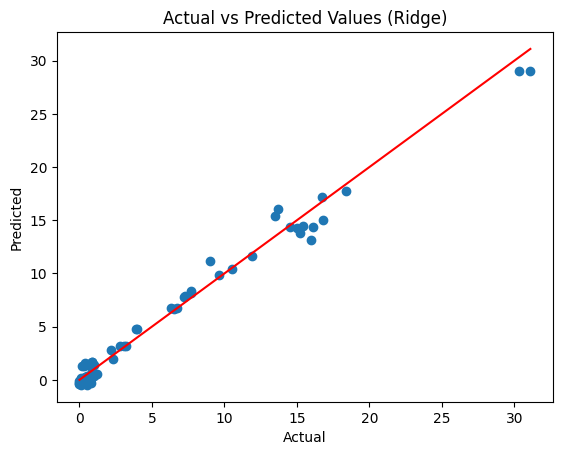

In [51]:
y_pred_best = y_pred_ridge 
plt.scatter(y_test, y_pred_best)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values (Ridge)")
plt.show()

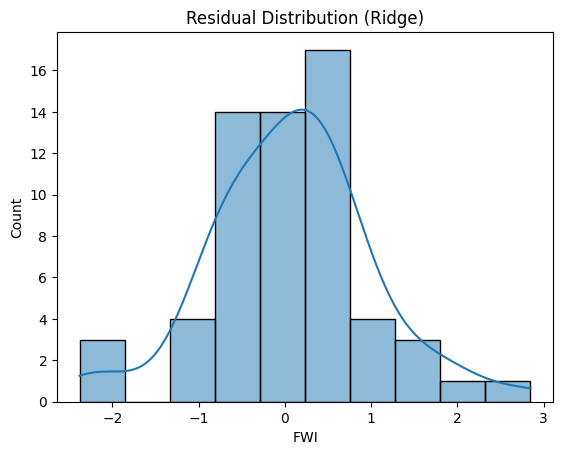

In [52]:
residuals = y_test - y_pred_best
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (Ridge)")
plt.show()

The scatter plot of actual vs predicted values shows that predictions are closely aligned with the diagonal line, indicating strong model performance and high predictive accuracy.

The residual distribution appears approximately normal and centered around zero, suggesting that the model does not exhibit significant bias and that the assumptions of linear regression are reasonably satisfied.

## 📊 Conclusion 

The results indicate that simple linear relationships between environmental variables (such as temperature, FFMC, and ISI) are strong predictors of fire risk. Linear Regression, Ridge, and Lasso models all achieved consistently high performance, with R² scores around 0.98, suggesting that increasing model complexity does not significantly improve predictive power.

Cross-validation results further confirm that these models generalize well across different data splits, indicating that the findings are robust and not dependent on a single train-test split. In particular, Ridge and Lasso models demonstrate stable and reliable performance, with Lasso providing the additional benefit of feature selection.

From a business perspective, this means that fire risk can be effectively monitored and predicted using relatively simple, interpretable, and computationally efficient models. This enables faster decision-making for early intervention and resource allocation.

For example, authorities can prioritize regions with high temperature and dryness indicators, allowing proactive fire prevention strategies and optimized deployment of firefighting resources. Additionally, the use of interpretable models reduces model risk and increases trust in decision-making processes.